In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
import os
from pathlib import Path
from IPython.display import clear_output
import time
import math

In [6]:
def get_os_agnostic_path(path_str):
    """Safely converts Linux or Windows paths to the current native OS format."""
    if pd.isna(path_str):
        return None
    # Force replacement of both slash types to the native OS separator
    clean_path = str(path_str).replace('\\', os.sep).replace('/', os.sep)
    return Path(clean_path)

In [7]:
MERGED_CSV_PATH = r"C:\Users\KostasPikounis\OneDrive_Inlecom_Personal\OneDrive - INLECOM\Amfitrite\task2\OWD\tiles\merged_2_windows_paths.csv"
SUMMARY_CSV_PATH = r"C:\Users\KostasPikounis\OneDrive_Inlecom_Personal\OneDrive - INLECOM\Amfitrite\task2\OWD\tiles\non_HABs_counterparts_metadata_v3\summary_report_merged_2_HABs_satelite_items_all_parts_windows_paths.csv"

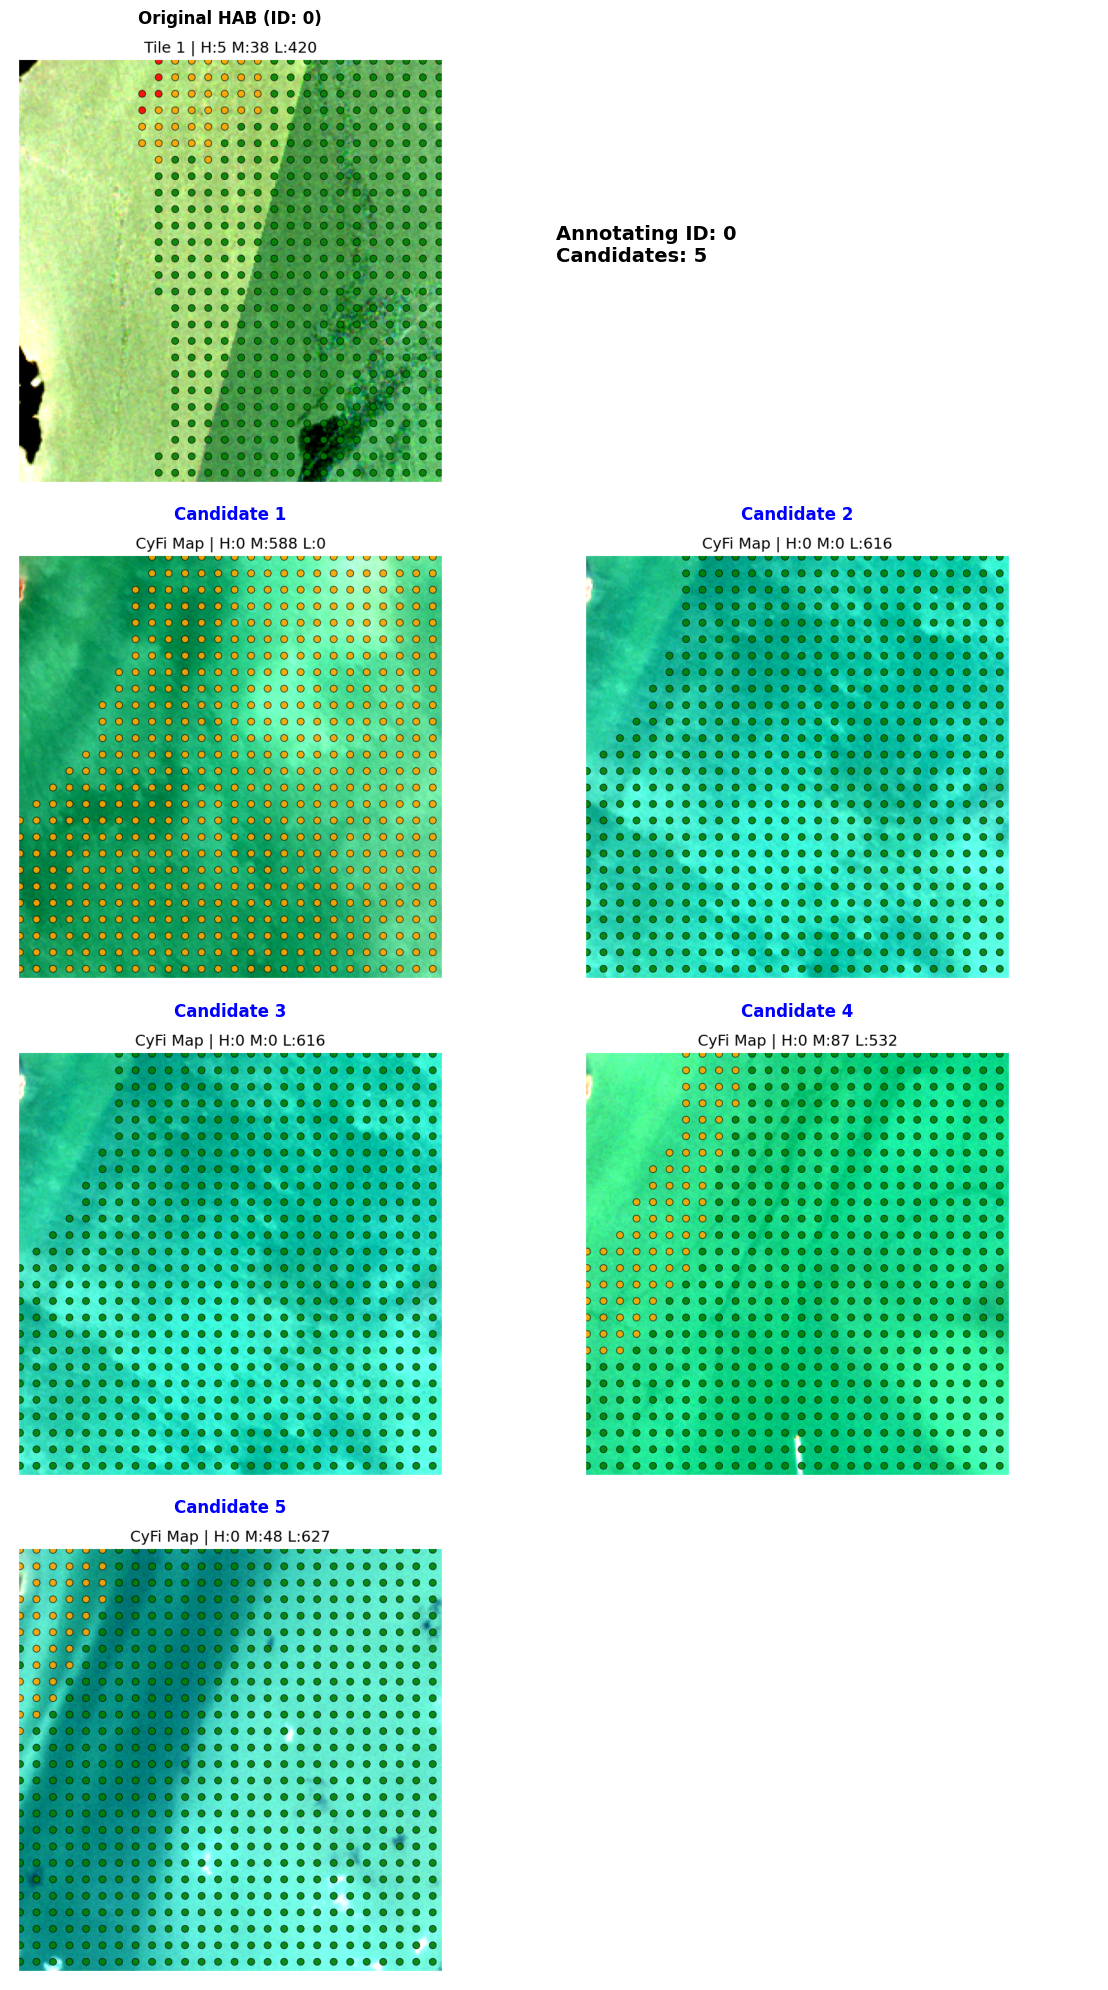

--- Candidate 1 ---
Class: To Be Checked | Total Index: 17.4
Clouds: 0.0% | Water Px: 65522
CyFi -> High: 0, Mod: 588, Low: 0
CNNs -> res18: NO/NO | convnext: NO | rdnet: NO

--- Candidate 2 ---
Class: Clean | Total Index: 0.0
Clouds: 0.0% | Water Px: 65512
CyFi -> High: 0, Mod: 0, Low: 629
CNNs -> res18: NO/NO | convnext: NO | rdnet: NO

--- Candidate 3 ---
Class: Clean | Total Index: 0.0
Clouds: 0.0% | Water Px: 65512
CyFi -> High: 0, Mod: 0, Low: 616
CNNs -> res18: NO/NO | convnext: NO | rdnet: NO

--- Candidate 4 ---
Class: To Be Checked | Total Index: 2.57
Clouds: 0.0% | Water Px: 65512
CyFi -> High: 0, Mod: 87, Low: 532
CNNs -> res18: NO/NO | convnext: NO | rdnet: NO

--- Candidate 5 ---
Class: To Be Checked | Total Index: 1.42
Clouds: 0.0% | Water Px: 65514
CyFi -> High: 0, Mod: 48, Low: 627
CNNs -> res18: NO/NO | convnext: NO | rdnet: NO

Enter selected candidates separated by commas (e.g., '1, 3').
Press ENTER to reject all. Include '0' anywhere to save and EXIT.


In [ ]:
# Load the original HABs dictionary
df_merged = pd.read_csv(MERGED_CSV_PATH, low_memory=False)

# Check if we are starting fresh or resuming
if not SUMMARY_CSV_PATH.endswith("_processed.csv"):
    print(f"Creating new processed tracking file...")
    df_summary = pd.read_csv(SUMMARY_CSV_PATH)
    df_summary['processed'] = 0
    df_summary['selected'] = 0
    
    # Create the new filename
    base_name = os.path.splitext(SUMMARY_CSV_PATH)[0]
    processed_csv_path = f"{base_name}_processed.csv"
    
    # Save it immediately
    df_summary.to_csv(processed_csv_path, index=False)
else:
    print(f"Resuming from existing tracking file...")
    processed_csv_path = SUMMARY_CSV_PATH
    df_summary = pd.read_csv(processed_csv_path)

# Find all unique IDs that haven't been processed yet
unprocessed_ids = df_summary[df_summary['processed'] == 0]['case_id'].unique()

unprocessed_ids = df_summary[df_summary['processed'] == 0]['case_id'].unique()

if len(unprocessed_ids) == 0:
    print("All cases have been processed! No pending annotations.")
else:
    for case_id in unprocessed_ids:
        clear_output(wait=True)
        
        # 1. Fetch Original HAB Data
        orig_row = df_merged[df_merged['ID'] == case_id]
        if orig_row.empty:
            print(f"Warning: Case ID {case_id} not found in {MERGED_CSV_PATH}. Skipping.")
            df_summary.loc[df_summary['case_id'] == case_id, 'processed'] = 1
            df_summary.to_csv(processed_csv_path, index=False)
            continue
            
        orig_folder = get_os_agnostic_path(orig_row.iloc[0]['tile_folder_path'])
        orig_img_path = orig_folder / "cyfi_prediction_map.png" if orig_folder else None
        
        # 2. Fetch Candidate Data
        candidates = df_summary[(df_summary['case_id'] == case_id) & (df_summary['processed'] == 0)]
        num_cands = len(candidates)
        cand_indices = candidates.index.tolist()
        
        # 3. Setup Visualization (Matrix: 2 Columns)
        # Calculate rows needed: 1 row for the Original + enough rows for candidates (2 per row)
        num_rows = 1 + math.ceil(num_cands / 2)
        
        fig, axes = plt.subplots(num_rows, 2, figsize=(12, 5 * num_rows))
        
        # Ensure 'axes' is always a 2D numpy array so we can index it safely as axes[row, col]
        axes = np.atleast_2d(axes) 
        
        # Hide all axes grids first
        for ax in axes.flatten():
            ax.axis('off')
        
        # Plot Original HAB on Row 0, Col 0
        try:
            axes[0, 0].imshow(imread(orig_img_path))
            axes[0, 0].set_title(f"Original HAB (ID: {case_id})", fontweight="bold")
        except Exception:
            axes[0, 0].text(0.5, 0.5, 'Image not found', ha='center', va='center')
            axes[0, 0].set_title(f"Original HAB (ID: {case_id})", fontweight="bold")
            
        # Optional: You can put text in the top right empty space (Row 0, Col 1)
        axes[0, 1].text(0.1, 0.5, f"Annotating ID: {case_id}\nCandidates: {num_cands}", fontsize=14, fontweight='bold')
        
        # Plot Candidates
        cand_details = []
        for i, idx in enumerate(cand_indices):
            # Math to place candidates in pairs starting from Row 1
            r = 1 + (i // 2)
            c = i % 2
            
            cand_row = candidates.loc[idx]
            cand_folder = get_os_agnostic_path(cand_row['output_folder'])
            cand_img_path = cand_folder / "cyfi_prediction_map.png" if cand_folder else None
            
            ax = axes[r, c]
            try:
                ax.imshow(imread(cand_img_path))
                ax.set_title(f"Candidate {i + 1}", fontweight="bold", color="blue")
            except Exception:
                ax.text(0.5, 0.5, 'Image not found', ha='center', va='center')
                ax.set_title(f"Candidate {i + 1}", fontweight="bold", color="blue")
            
            # Format the text block
            details = f"--- Candidate {i + 1} ---\n"
            details += f"Class: {cand_row['Overall_Class']} | Total Index: {cand_row['Total_Index']}\n"
            details += f"Clouds: {cand_row['Cloud_Percentage']}% | Water Px: {cand_row['SCL_Water_Pixels']}\n"
            details += f"CyFi -> High: {cand_row['CyFi_High']}, Mod: {cand_row['CyFi_Moderate']}, Low: {cand_row['CyFi_Low']}\n"
            details += f"CNNs -> res18: {cand_row['res18_scl']}/{cand_row['res18_no_scl']} | "
            details += f"convnext: {cand_row['convnext_scl']} | rdnet: {cand_row['rdnet_no_scl']}\n"
            cand_details.append(details)
            
        plt.tight_layout()
        plt.show()
        
        # 4. Print Candidate Metrics
        for d in cand_details:
            print(d)
            
        # 5. User Input Parsing (With rendering delay fix)
        print("=" * 60)
        print("Enter selected candidates separated by commas (e.g., '1, 3').")
        print("Press ENTER to reject all. Include '0' anywhere to save and EXIT.")
        
        time.sleep(0.2) # Forces VS Code to finish rendering the UI before opening input box
        user_input = input("Selection: ")
        
        selected_nums = []
        exit_flag = False
        
        if user_input.strip() != "":
            parts = user_input.split(",")
            for p in parts:
                p = p.strip()
                if p.isdigit():
                    num = int(p)
                    if num == 0:
                        exit_flag = True
                    elif 1 <= num <= num_cands:
                        selected_nums.append(num)
                        
        # 6. Update DataFrame State
        df_summary.loc[cand_indices, 'processed'] = 1
        for num in selected_nums:
            real_idx = cand_indices[num - 1]
            df_summary.loc[real_idx, 'selected'] = 1
            
        df_summary.to_csv(processed_csv_path, index=False)
        
        # 7. Check Exit Condition
        if exit_flag:
            clear_output(wait=True)
            remaining = len(df_summary[df_summary['processed'] == 0]['case_id'].unique())
            print(f"Progress safely saved to {processed_csv_path}.")
            print(f"Remaining unique cases to annotate: {remaining}")
            break

    if not exit_flag and len(df_summary[df_summary['processed'] == 0]['case_id'].unique()) == 0:
        clear_output(wait=True)
        print("All cases have been annotated and saved!")